### Step 1: Install and Import Libraries, and Load the Dataset

In [1]:
# Install prophet if not already present, though it is usually pre-installed in Google Colab
!pip install -q prophet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_squared_log_error

# Load the training data
df = pd.read_csv('/content/train.csv')

# Display basic info and first few rows
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
display(df.info())
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (3000888, 6)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


None


First 5 Rows:


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


### Step 2: Exploratory Data Analysis & Visualization
Let's aggregate the sales on a daily level to visualize the overall timeline trend.

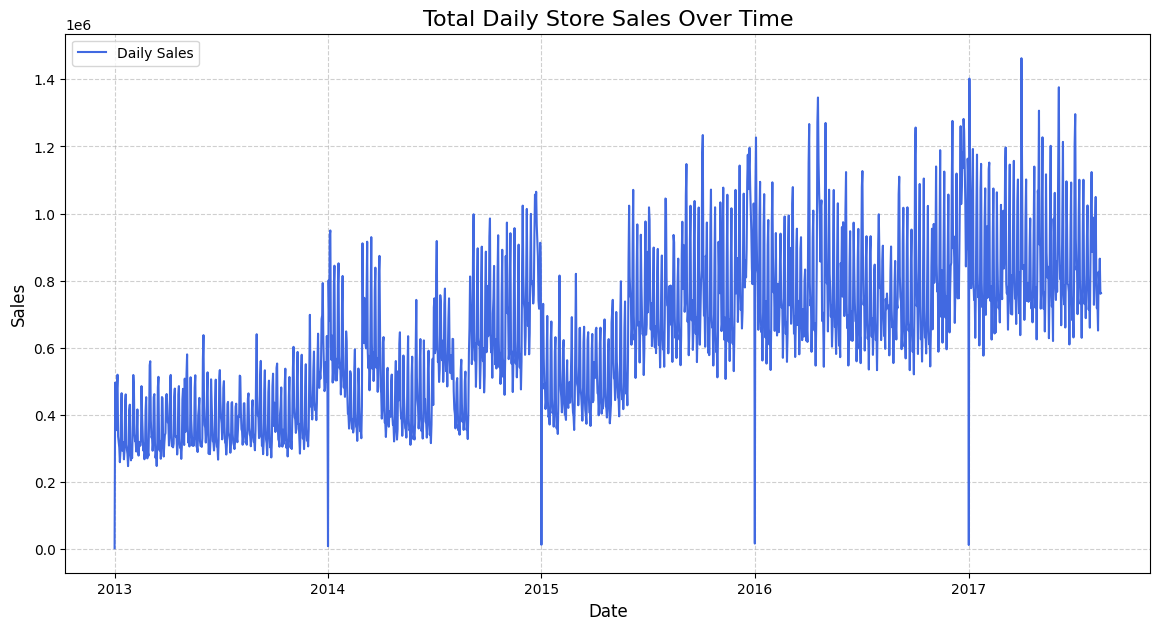

In [3]:
# Ensure date column is parsed correctly
df['date'] = pd.to_datetime(df['date'])

# Aggregate sales daily
daily_sales = df.groupby('date')['sales'].sum().reset_index()

# Plot daily sales
plt.figure(figsize=(14, 7))
plt.plot(daily_sales['date'], daily_sales['sales'], label='Daily Sales', color='royalblue')
plt.title('Total Daily Store Sales Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### Step 3: Data Preprocessing for Prophet
Prophet expects a dataframe with two columns: `ds` (date) and `y` (target value). We will use the aggregated daily sales dataset and split it into training and testing sets to evaluate our model's RMSLE.

In [4]:
# Rename columns to ds and y
prophet_df = daily_sales.rename(columns={'date': 'ds', 'sales': 'y'})

# Split into train and test sets (e.g., reserving the last 30 days for evaluation)
test_days = 30
train_df = prophet_df.iloc[:-test_days]
test_df = prophet_df.iloc[-test_days:]

print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape: {test_df.shape}")

Training data shape: (1654, 2)
Testing data shape: (30, 2)


### Step 4: Model Training, Forecasting, and Evaluation
We will initialize and fit the Prophet model on the training data, make predictions over the test period, and compute the RMSLE score.

In [5]:
# Initialize and train Prophet model
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(train_df)

# Create a dataframe for future predictions covering the test period
future = model.make_future_dataframe(periods=test_days, freq='D')
forecast = model.predict(future)

# Extract predictions for the test period
predictions = forecast.iloc[-test_days:][['ds', 'yhat']]

# Merge predictions with actuals to calculate evaluation metrics
evaluation_df = pd.merge(test_df, predictions, on='ds')

# Ensure no negative predictions for RMSLE calculation
evaluation_df['yhat'] = evaluation_df['yhat'].clip(lower=0)

# Calculate Root Mean Squared Logarithmic Error (RMSLE)
rmsle = np.sqrt(mean_squared_log_error(evaluation_df['y'], evaluation_df['yhat']))
print(f"Validation RMSLE over the last {test_days} days: {rmsle:.4f}")

Validation RMSLE over the last 30 days: 0.0989


### Step 5: Visualize Predictions and Forecast Components

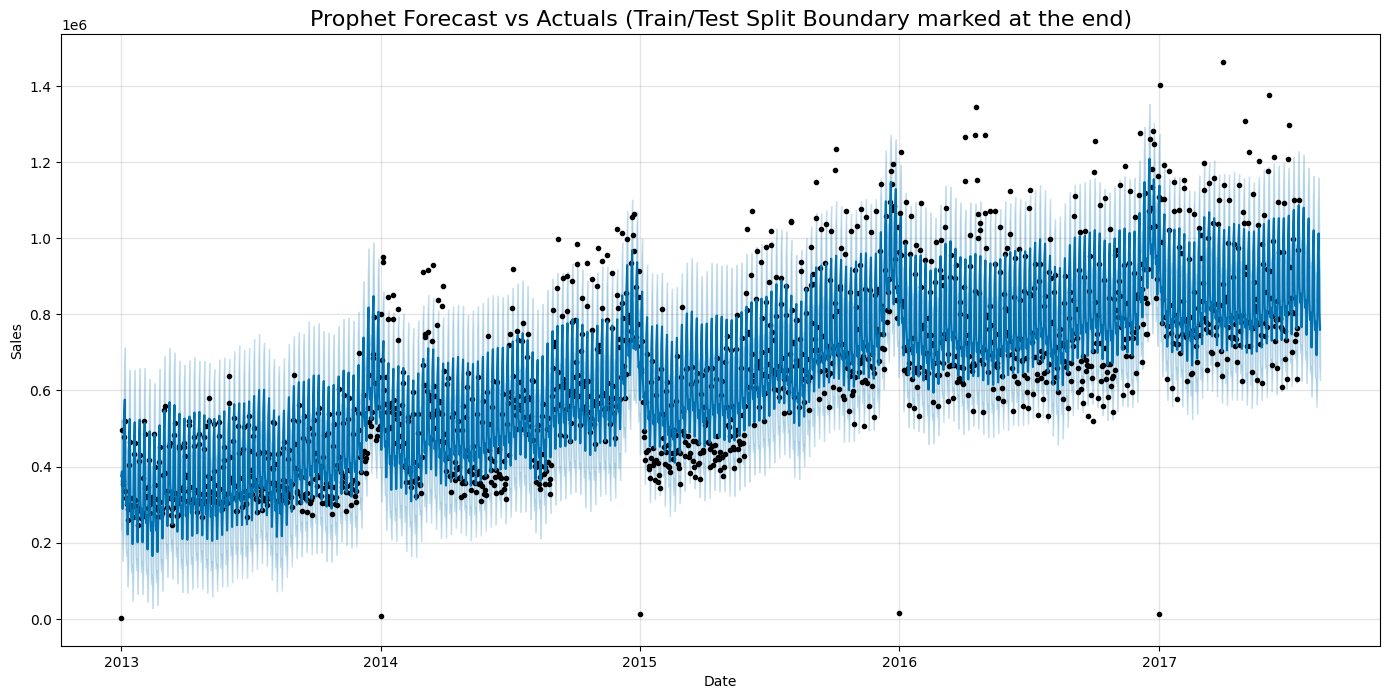

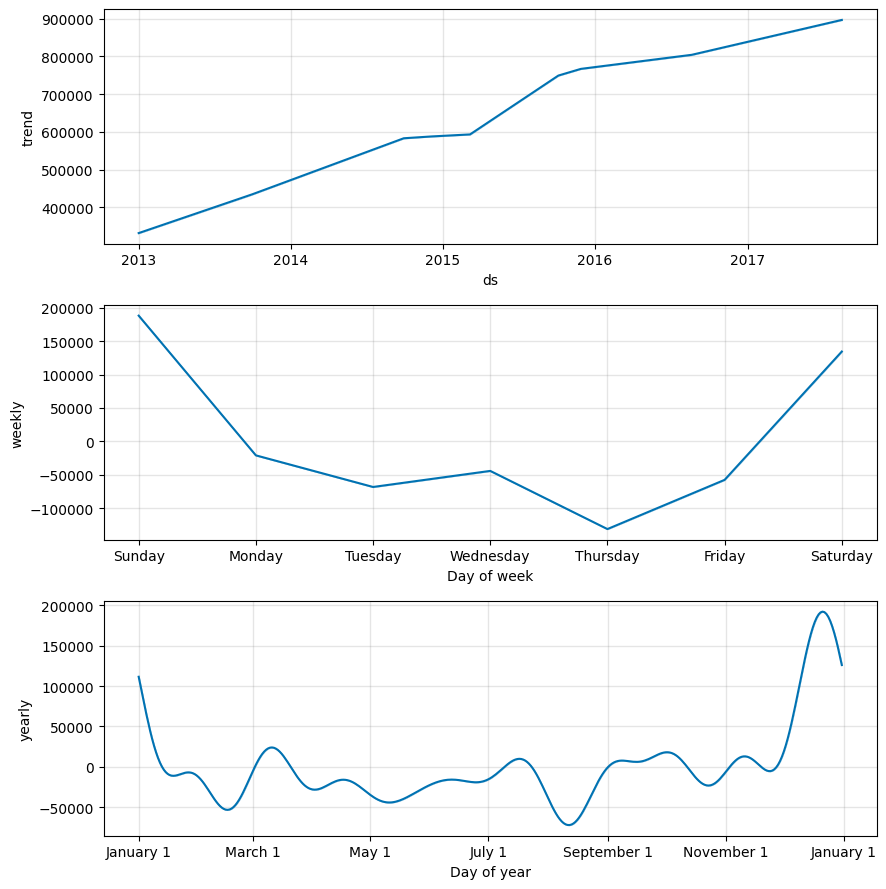

In [6]:
# Plot the actuals vs forecast
fig1 = model.plot(forecast, figsize=(14, 7))
plt.title('Prophet Forecast vs Actuals (Train/Test Split Boundary marked at the end)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

# Plot the components of the forecast (trend, weekly, and yearly seasonal patterns)
fig2 = model.plot_components(forecast)
plt.show()

In [8]:
# Export the forecast DataFrame to a CSV file
forecast.to_csv('/content/forecast_output.csv', index=False)
print("Forecast successfully exported to: /content/forecast_output.csv")

Forecast successfully exported to: /content/forecast_output.csv


In [9]:
from google.colab import files

# Trigger browser download of the exported forecast file
files.download('/content/forecast_output.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>